In [1]:
print("Python is working!")

Python is working!


In [3]:
# Import required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df['species'] = iris.target

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
df.describe()

Dataset Shape: (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Convert species numbers into flower names

df['species_name'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

# Check the number of samples in each species
print("Species Distribution:")
print(df['species_name'].value_counts())

Species Distribution:
species_name
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


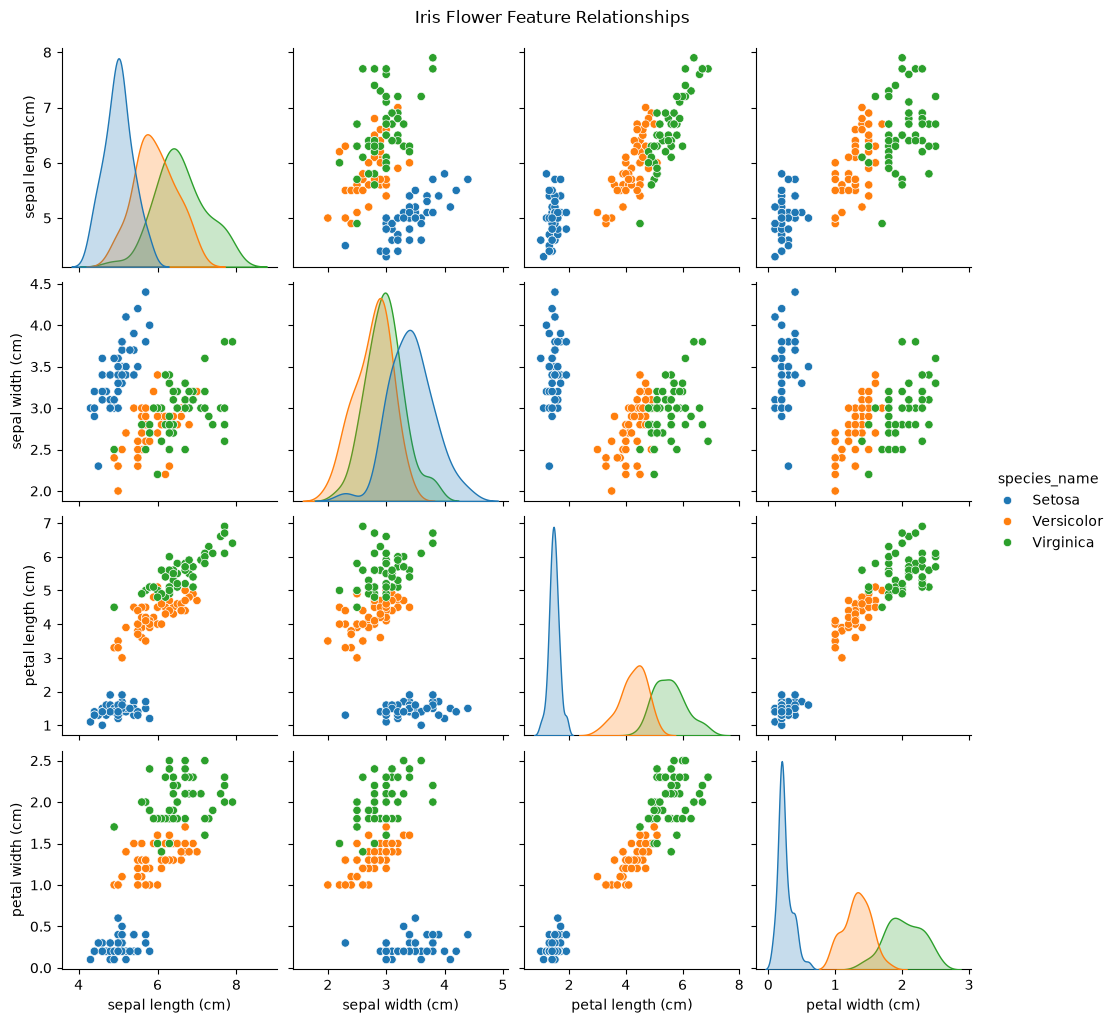

In [7]:
# Pairplot to visualize relationships between flower features

sns.pairplot(
    df,
    hue='species_name',
    vars=[
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)'
    ]
)

plt.suptitle('Iris Flower Feature Relationships', y=1.02)
plt.show()

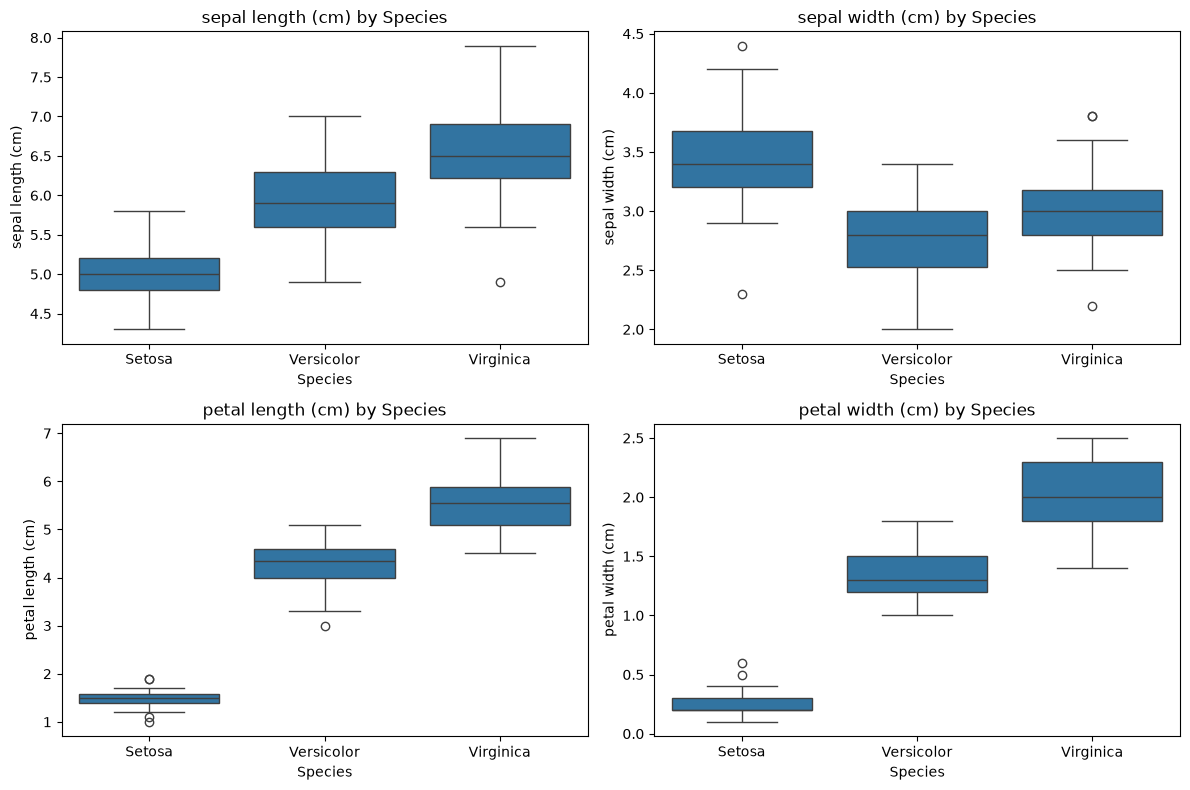

In [8]:
# Box plots for all four features

plt.figure(figsize=(12, 8))

features = [
    'sepal length (cm)',
    'sepal width (cm)',
    'petal length (cm)',
    'petal width (cm)'
]

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='species_name', y=feature)
    plt.title(f'{feature} by Species')
    plt.xlabel('Species')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [9]:
# Prepare features and target

X = df[
    [
        'sepal length (cm)',
        'sepal width (cm)',
        'petal length (cm)',
        'petal width (cm)'
    ]
]

y = df['species']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


In [10]:
# Train Logistic Regression model

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Accuracy Percentage:", logistic_accuracy * 100, "%")

Logistic Regression Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %


In [13]:
# Evaluate Logistic Regression
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names
))


# Evaluate KNN
print("\n=== K-Nearest Neighbors ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=iris.target_names
))

=== Logistic Regression ===
Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


=== K-Nearest Neighbors ===


NameError: name 'y_pred_knn' is not defined

In [14]:
# Train K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy Percentage:", knn_accuracy * 100, "%")

KNN Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [15]:
# Compare model performance

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'K-Nearest Neighbors'],
    'Accuracy': [logistic_accuracy, knn_accuracy]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,K-Nearest Neighbors,1.000000,100.000000


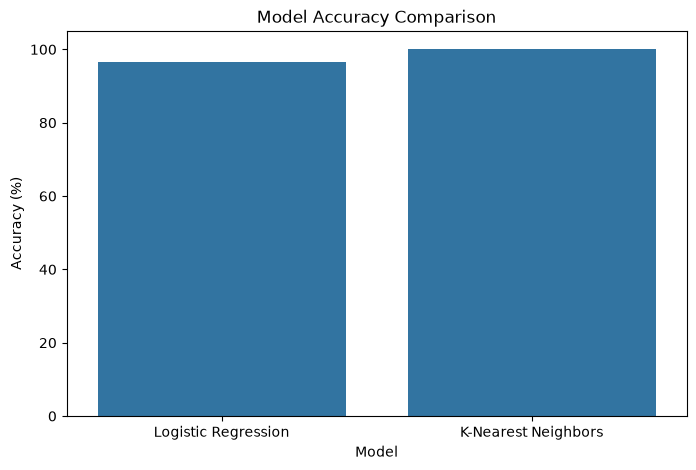

In [16]:
# Visual comparison of model accuracy

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy (%)'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)

plt.show()

## Conclusion

The Iris Flower Classification project was successfully completed using
Logistic Regression and K-Nearest Neighbors (KNN).

- Logistic Regression achieved an accuracy of 96.67%.
- K-Nearest Neighbors (KNN) achieved an accuracy of 100%.
- KNN performed better on the test dataset and was selected as the best-performing model.
- The models successfully classified the Iris flowers into Setosa, Versicolor, and Virginica classes.

Overall, the project demonstrated the use of data exploration, visualization,
model training, evaluation, and comparison for a classification problem.